### Import packages

In [2]:
import os
import zipfile
import pandas as pd
import glob
import numpy as np
import warnings
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import re

### The code below will process the data based on the virus name user provided

In [3]:
def readChemblCsvFile(filePath):
    """
    Read ChEMBL CSV file with proper handling of semicolon delimiter and quotes.
    """
    print(f"Reading ChEMBL CSV file: {filePath}")
    if not os.path.exists(filePath):
        print(f"Error: File not found at {filePath}")
        return None
    try:
        dataFrame = pd.read_csv(
            filePath,
            sep=';',                        # Semicolon separator
            quotechar='"',                  # Double quotes
            quoting=csv.QUOTE_ALL,          # All fields quoted
            doublequote=True,               # Handle double quotes within quotes
            skipinitialspace=True,          # Skip spaces after delimiter
            on_bad_lines='skip',            # Skip malformed lines
            encoding='utf-8',
            low_memory=False                # Read entire file into memory for consistency
        )
        return dataFrame
    except Exception as e:
        print(f"Standard pandas method failed: {e}")
        return None

def splitSemicolonRobust(line: str):
    """
    Robustly splits a line by semicolons, handling quotes.
    """
    fields, cur = [], []
    inQuote = False
    i = 0
    while i < len(line):
        ch = line[i]
        if ch == '"':
            if inQuote and i + 1 < len(line) and line[i+1] == '"':
                cur.append('"')
                i += 2
                continue
            inQuote = not inQuote
            i += 1
            continue
        if ch == ';' and not inQuote:
            fields.append(''.join(cur))
            cur = []
            i += 1
            continue
        cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

def processVirusData(virusName):
    """
    Main function to process bioactivity and compound data for a given virus.
    """
   
    if not os.path.exists(virusDataDir):
        print(f"Error: Data directory for '{virusName}' not found at {virusDataDir}")
        return

    # ### ChEMBL Bioassay Data
    print("\n--- Processing Bioassay Data ---")
    bioactivityFile = os.path.join(virusDataDir, f'{virusName}_bioactivity.csv')
    chemblData = readChemblCsvFile(bioactivityFile)

    if chemblData is None:
        return

    print(f"Dataset loaded successfully with Shape: {chemblData.shape}")

    # #### Keep only relevant properties
    selectedColumns = ['Smiles', 'Standard Value', 'Standard Units', 'Standard Type',
                      'Standard Relation', 'pChEMBL Value', 'Molecule ChEMBL ID',
                      'Molecular Weight', 'AlogP', 'Target ChEMBL ID',
                      'Target Name', 'Target Organism']

    chemblDataCleaned = chemblData[[col for col in selectedColumns if col in chemblData.columns]].copy()
    print(f"Dataset shape after selecting columns: {chemblData.shape} → {chemblDataCleaned.shape}")
    
    outputPath = os.path.join(modelBuildingDataDir, f'{virusName}Bioassay_chEMBL_cleaned.csv')
    chemblDataCleaned.to_csv(outputPath, index=False)
    print(f"Cleaned bioassay data saved to: {outputPath}")

    # ### Count Standard Type and Generate Plot
    print("\n--- Analyzing Standard Types ---")
    typeCounts = chemblDataCleaned["Standard Type"].value_counts()
    total = typeCounts.sum()
    legendLabels = [f"{stype} ({count}, {count/total:.1%})" for stype, count in typeCounts.items()]

    plt.figure(figsize=(10, 8))
    wedges, texts, autotexts = plt.pie(
        typeCounts, labels=typeCounts.index, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 9}
    )
    plt.legend(wedges, legendLabels, title="Standard Type", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(f"Distribution of Standard Types for {virusName}")
    plt.tight_layout()
    plotPath = os.path.join(modelBuildingDataDir, f'{virusName}_standard_types.png')
    plt.savefig(plotPath)
    print(f"Standard types plot saved to: {plotPath}")
    plt.show()

    # ### Check for empty (NaN) values
    print("\n--- Checking for NaN values ---")
    nanCounts = chemblDataCleaned.isnull().sum()
    totalRows = len(chemblDataCleaned)
    for column, nanCount in nanCounts.items():
        percentage = (nanCount / totalRows) * 100
        print(f"{column:25s}: {nanCount:6,} ({percentage:5.1f}%)")

    # ### Count unique compounds
    if "Molecule ChEMBL ID" in chemblDataCleaned.columns:
        uniqueCount = chemblDataCleaned["Molecule ChEMBL ID"].nunique()
        print(f"\nNumber of unique compounds for {virusName}: {uniqueCount}")

    # ### ChEMBL compounds data
    print("\n--- Processing Compounds Data ---")
    compoundsFile = os.path.join(virusDataDir, f'{virusName}_compounds.csv')
    if not os.path.exists(compoundsFile):
        print(f"Error: Compounds file not found at {compoundsFile}")
        return

    with open(compoundsFile, "r", encoding="utf-8", errors="replace") as f:
        rawLines = [ln.rstrip("\n") for ln in f]

    header = splitSemicolonRobust(rawLines[0])
    ncols = len(header)
    rows = [header]
    buffer = ""
    for line in rawLines[1:]:
        buffer = f"{buffer}\n{line}" if buffer else line
        parsed = splitSemicolonRobust(buffer)
        if len(parsed) == ncols:
            rows.append(parsed)
            buffer = ""
    if buffer:
        parsed = splitSemicolonRobust(buffer)
        parsed += [""] * (ncols - len(parsed)) if len(parsed) < ncols else []
        rows.append(parsed[:ncols])

    chemblCompoundData = pd.DataFrame(rows[1:], columns=header)
    chemblCompoundData.columns = [re.sub(r"[^\w]+", "_", c).strip("_").lower() for c in chemblCompoundData.columns]
    
    # Standardize the ChEMBL ID column name for merging
    if 'molecule_chembl_id' in chemblCompoundData.columns:
        chemblCompoundData = chemblCompoundData.rename(columns={'molecule_chembl_id': 'chembl_id'})

    numCols = ["molecular_weight", "alogp", "polar_surface_area", "hba", "hbd", "ro5_violations", "rotatable_bonds", "qed_weighted", "heavy_atoms"]
    for c in numCols:
        if c in chemblCompoundData.columns:
            chemblCompoundData[c] = pd.to_numeric(chemblCompoundData[c], errors="coerce")
    
    print(f"Compounds data shape: {chemblCompoundData.shape}")
    outputPath = os.path.join(modelBuildingDataDir, f'{virusName}Compounds_chEMBL_cleaned.csv')
    chemblCompoundData.to_csv(outputPath, index=False)
    print(f"Cleaned compounds data saved to: {outputPath}")

    # ### Combine Bioassay and Compound Data
    print("\n--- Combining Bioassay and Compound Data ---")
    colsToImport = ['chembl_id', 'type', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds', 'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations', 'molecular_formula', 'inchi_key', 'inchi']
    cmpdSub = chemblCompoundData.loc[:, [c for c in colsToImport if c in chemblCompoundData.columns]].copy()

    chemblDataCombined = chemblDataCleaned.merge(
        cmpdSub, how='left', left_on='Molecule ChEMBL ID', right_on='chembl_id', suffixes=('', '_cmp')
    )
    if 'chembl_id' in chemblDataCombined.columns:
        chemblDataCombined = chemblDataCombined.drop(columns=['chembl_id'])

    # ### Final Reordering and Saving
    chemblDataCombined = chemblDataCombined.rename(columns={
        "Smiles": "smiles", "Standard Value": "standard_value", "Standard Units": "standard_units",
        "Standard Type": "standard_type", "Standard Relation": "standard_relation", "pChEMBL Value": "pchembl_value",
        "Molecule ChEMBL ID": "molecule_chembl_id", "Molecular Weight": "molecular_weight",
    })

    desiredOrder = [
        "molecule_chembl_id", "smiles", "molecular_formula", "inchi_key", "inchi", "molecular_weight", "type",
        "standard_value", "standard_units", "standard_relation", "standard_type", "pchembl_value", "AlogP",
        "polar_surface_area", "hba", "hbd", "rotatable_bonds", "qed_weighted", "heavy_atoms", "aromatic_rings",
        "ro5_violations", "Target ChEMBL ID", "Target Name", "Target Organism"
    ]
    
    existing = [c for c in desiredOrder if c in chemblDataCombined.columns]
    extras = [c for c in chemblDataCombined.columns if c not in existing]
    newColOrder = existing + extras

    chemblDataCombined = chemblDataCombined[newColOrder]

    outputPath = os.path.join(modelBuildingDataDir, f'{virusName}Data_chEMBL_combined.csv')
    chemblDataCombined.to_csv(outputPath, index=False)
    print(f"Final combined data saved to: {outputPath} with shape {chemblDataCombined.shape}")
    print("\nProcessing complete.")
    
    # Display the final combined dataframe head
    # In a .py script run in Jupyter, we need to explicitly import and use display
    #from IPython.display import display
    #print("\n--- First 5 rows of final combined data ---")
    #display(chemblDataCombined.head())



### Define data paths

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData')

# Processing data files for `Ebola` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Ebola/Ebola_bioactivity.csv
Dataset loaded successfully with Shape: (956, 48)
Dataset shape after selecting columns: (956, 48) → (956, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Ebola_standard_types.png


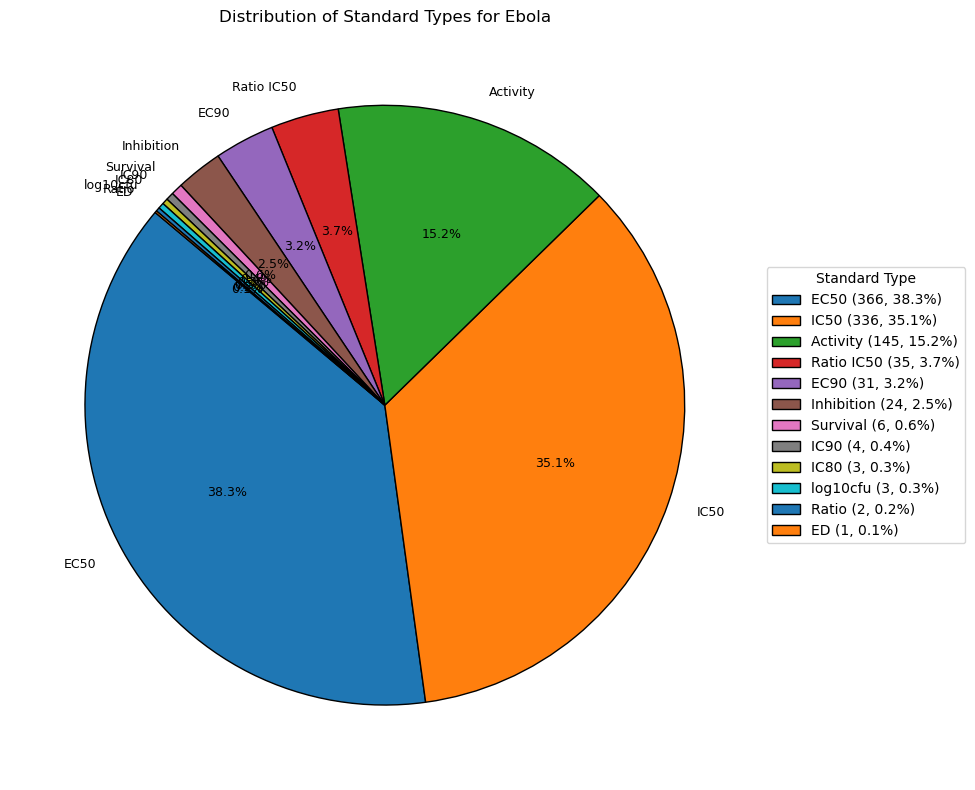


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     75 (  7.8%)
Standard Units           :    106 ( 11.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     75 (  7.8%)
pChEMBL Value            :    347 ( 36.3%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      6 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Ebola: 582

--- Processing Compounds Data ---
Compounds data shape: (582, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaData_chEMBL_combined.csv 

In [5]:
virusName = 'Ebola'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Marburg` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Marburg/Marburg_bioactivity.csv
Dataset loaded successfully with Shape: (227, 48)
Dataset shape after selecting columns: (227, 48) → (227, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Marburg_standard_types.png


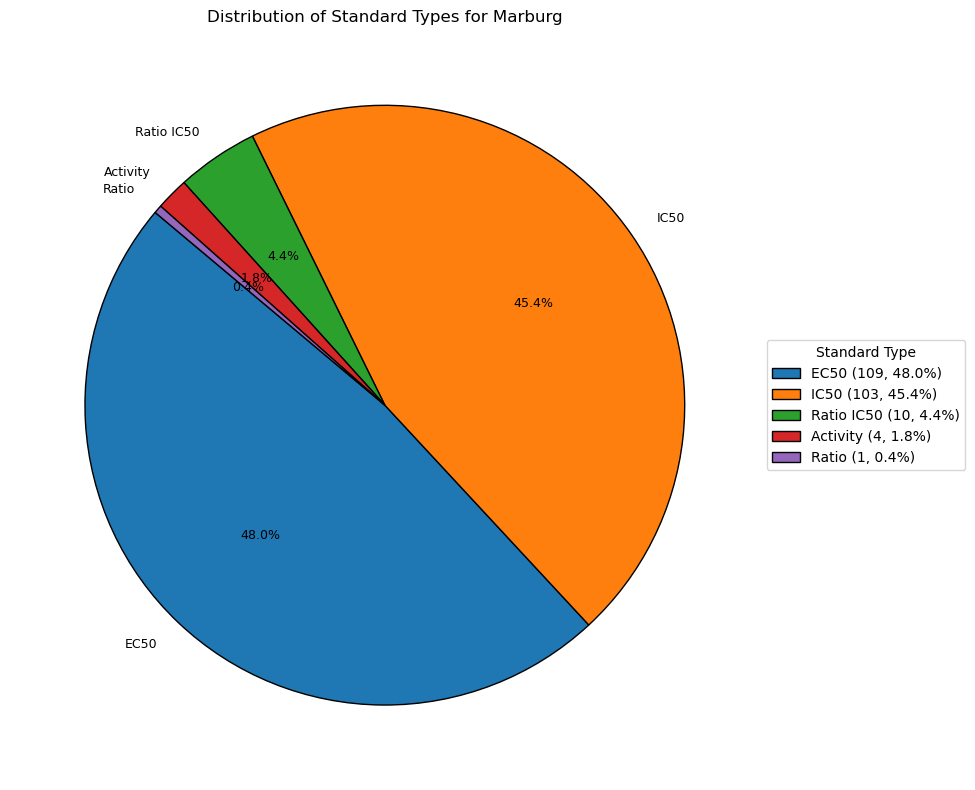


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     12 (  5.3%)
Standard Units           :     23 ( 10.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     12 (  5.3%)
pChEMBL Value            :     48 ( 21.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Marburg: 170

--- Processing Compounds Data ---
Compounds data shape: (170, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgData_chEMBL_combine

In [6]:
virusName = 'Marburg'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Lassa` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Lassa/Lassa_bioactivity.csv
Dataset loaded successfully with Shape: (234, 48)
Dataset shape after selecting columns: (234, 48) → (234, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Lassa_standard_types.png


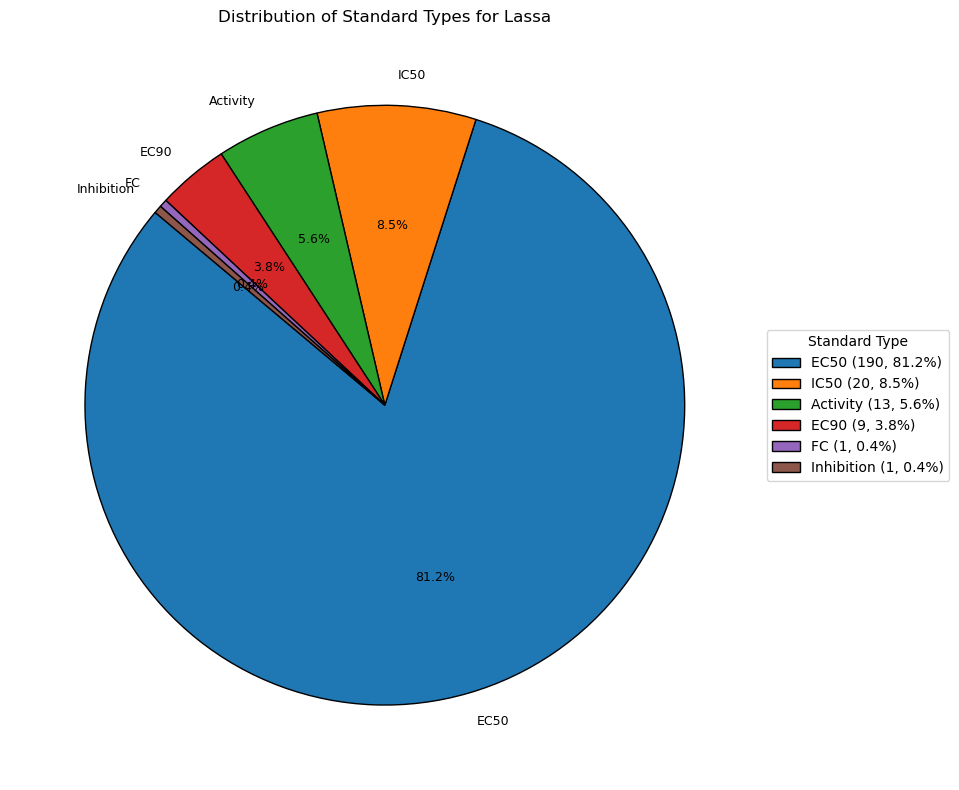


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     14 (  6.0%)
Standard Units           :     14 (  6.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     14 (  6.0%)
pChEMBL Value            :     46 ( 19.7%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Lassa: 211

--- Processing Compounds Data ---
Compounds data shape: (211, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaData_chEMBL_combined.csv 

In [7]:
virusName = 'Lassa'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Nipah` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Nipah/Nipah_bioactivity.csv
Dataset loaded successfully with Shape: (21, 48)
Dataset shape after selecting columns: (21, 48) → (21, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/NipahBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Nipah_standard_types.png


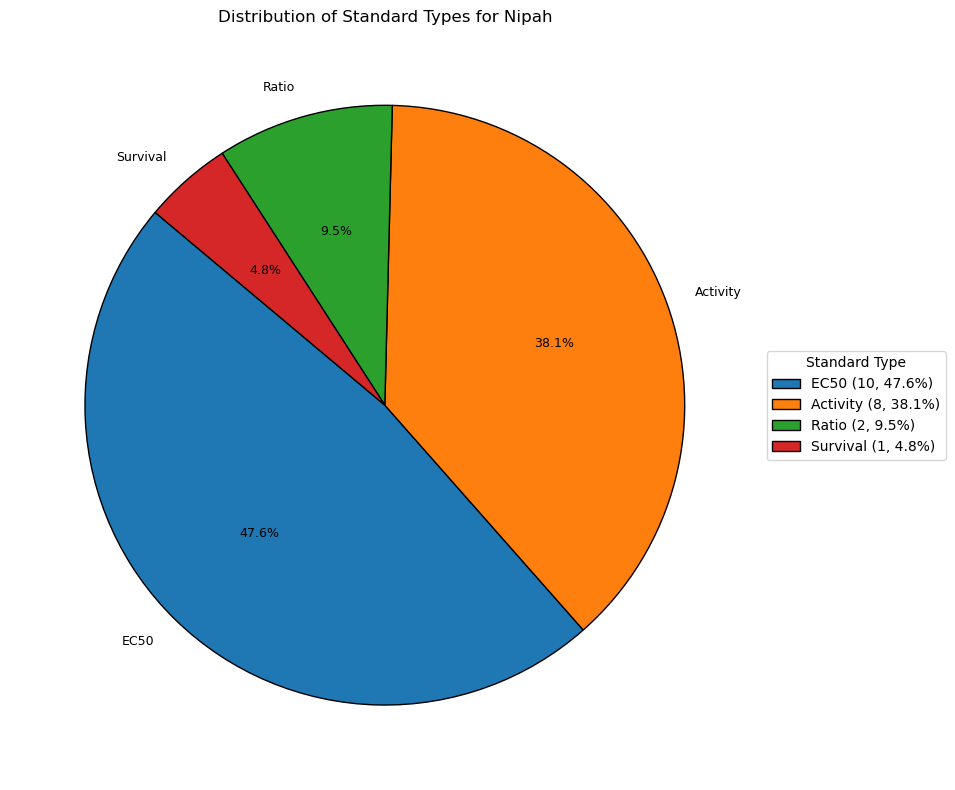


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :      8 ( 38.1%)
Standard Units           :     10 ( 47.6%)
Standard Type            :      0 (  0.0%)
Standard Relation        :      8 ( 38.1%)
pChEMBL Value            :     11 ( 52.4%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Nipah: 12

--- Processing Compounds Data ---
Compounds data shape: (12, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/NipahCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/NipahData_chEMBL_combined.csv wi

In [8]:
virusName = 'Nipah'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Venezuelan equine encephalitis virus (VEEV)`


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/VEEV/VEEV_bioactivity.csv
Dataset loaded successfully with Shape: (474, 48)
Dataset shape after selecting columns: (474, 48) → (474, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEVBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEV_standard_types.png


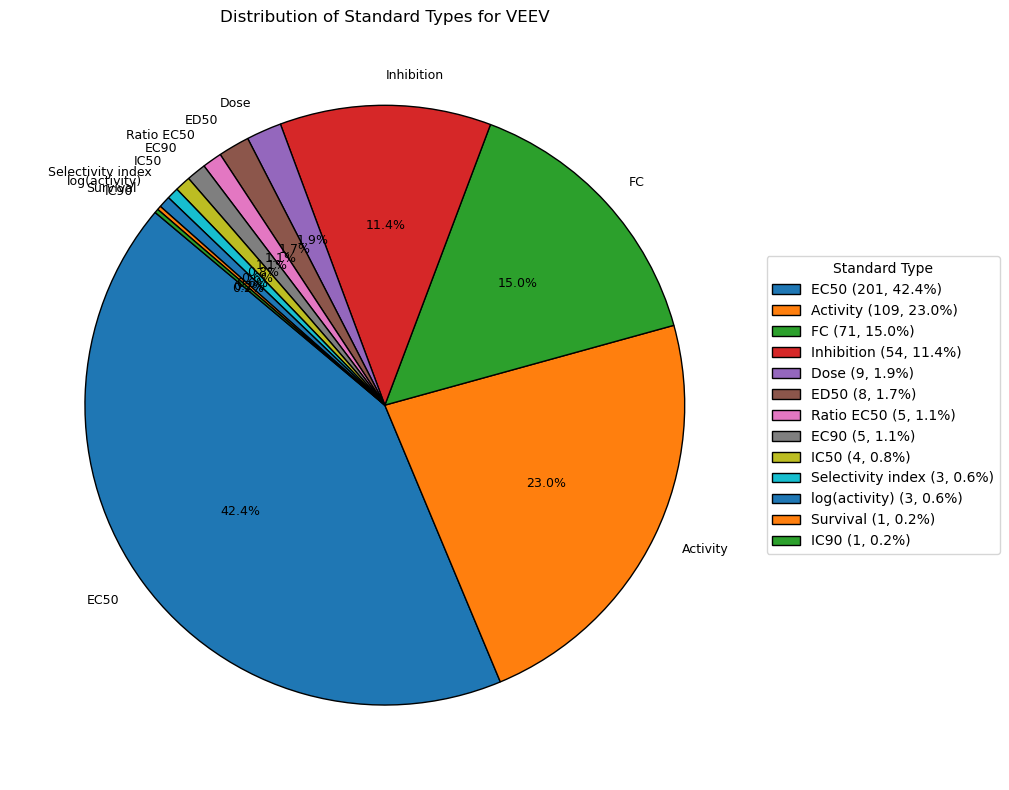


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :    112 ( 23.6%)
Standard Units           :    147 ( 31.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :    112 ( 23.6%)
pChEMBL Value            :    337 ( 71.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      1 (  0.2%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for VEEV: 275

--- Processing Compounds Data ---
Compounds data shape: (275, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEVCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEVData_chEMBL_combined.csv wit

In [9]:
virusName = 'VEEV'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Hantavirus`


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Hanta/Hanta_bioactivity.csv
Dataset loaded successfully with Shape: (157, 48)
Dataset shape after selecting columns: (157, 48) → (157, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/HantaBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Hanta_standard_types.png


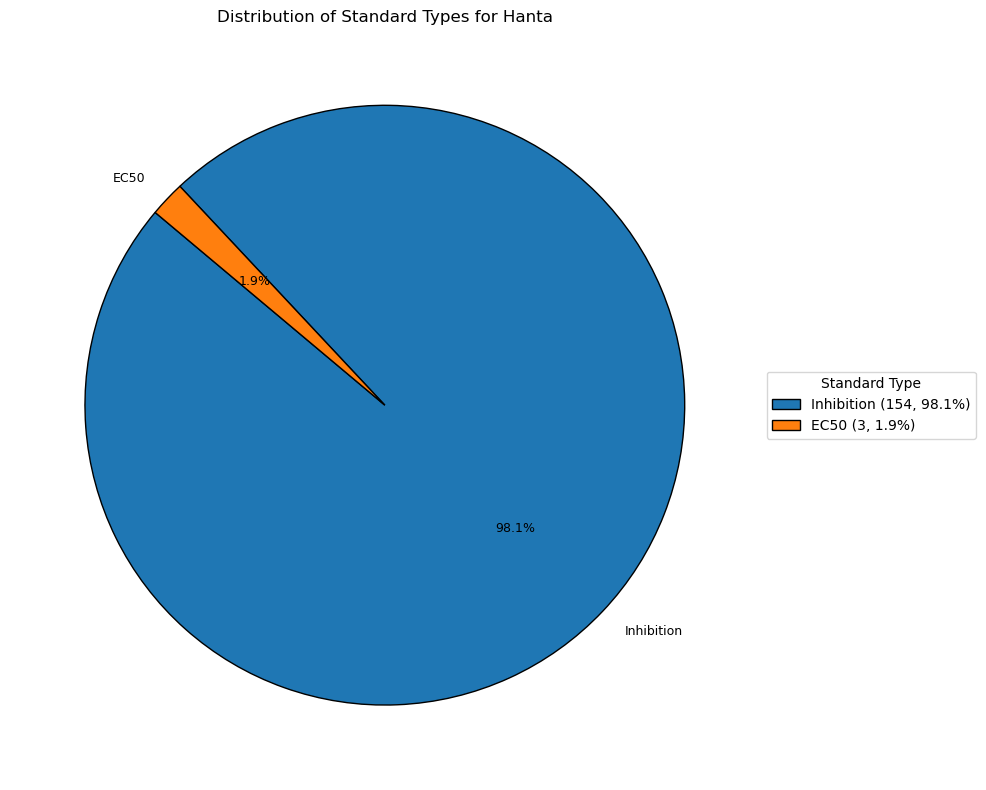


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     35 ( 22.3%)
Standard Units           :      0 (  0.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     35 ( 22.3%)
pChEMBL Value            :    154 ( 98.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      1 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Hanta: 119

--- Processing Compounds Data ---
Compounds data shape: (119, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/HantaCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/HantaData_chEMBL_combined.csv 

In [10]:
virusName = 'Hanta'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

### Combine the data set of all the viruses into one large data set

In [15]:
# Match your combined files
pattern = os.path.join(modelBuildingDataDir, "*Data_chEMBL_combined.csv")

# Find all matching files
fileList = glob.glob(pattern)
#print("\nFiles found:", fileList)

# Read and concatenate row-wise
dfList = []
for file in fileList:
    df = pd.read_csv(file)
    df["Virus"] = os.path.basename(file).replace("Data_chEMBL_combined.csv", "")  # add virus name column
    print(f"Loaded {os.path.basename(file):35s} → Shape: {df.shape}")
    dfList.append(df)

# Concatenate all
allVirusData_chEMBL = pd.concat(dfList, ignore_index=True)
print(f"\nFinal combined shape: {allVirusData_chEMBL.shape}")

# Save the combined dataframe
outFile = os.path.join(modelBuildingDataDir, "AllVirusData_chEMBL_combined.csv")
allVirusData_chEMBL.to_csv(outFile, index=False)
print(f"Saved merged CSV to: {outFile}")

Loaded NipahData_chEMBL_combined.csv       → Shape: (21, 25)
Loaded VEEVData_chEMBL_combined.csv        → Shape: (474, 25)
Loaded EbolaData_chEMBL_combined.csv       → Shape: (956, 25)
Loaded LassaData_chEMBL_combined.csv       → Shape: (234, 25)
Loaded MarburgData_chEMBL_combined.csv     → Shape: (227, 25)
Loaded HantaData_chEMBL_combined.csv       → Shape: (157, 25)

Final combined shape: (2069, 25)
Saved merged CSV to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/AllVirusData_chEMBL_combined.csv
